In [ ]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import neurokit2 as nk
import tdt
import spikeinterface.extractors as se
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from spikeinterface.extractors import SpikeGadgetsRecordingExtractor

c:\Users\sjs93\anaconda3\envs\resp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
datapath = r"E:\Aim1\hab_d0\4_7_hab_d0_20250620_190146.rec\4_7_hab_d0_20250620_190146_merged.rec"
#se.read is the class function used to read in spikegadgets it requres file path and stream id = trodes for ephys ECU is used for medpc
recording = se.read_spikegadgets(datapath, stream_id = 'trodes')
print(recording)

SpikeGadgetsRecordingExtractor: 32 channels - 20.0kHz - 1 segments - 12,359,768 samples 
                                617.99s (10.30 minutes) - int16 dtype - 754.38 MiB
  file_path: E:\Aim1\hab_d0\4_7_hab_d0_20250620_190146.rec\4_7_hab_d0_20250620_190146_merged.rec


In [ ]:
# Check the channel IDs, which might provide insight into the stream configuration
print(recording.channel_ids)


['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15'
 '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29'
 '30' '31']


In [ ]:
elec_noise_freq=60
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3130311/ paper suggested these min and max cut offs
min_freq=30
max_freq=1000
resample_rate=1000

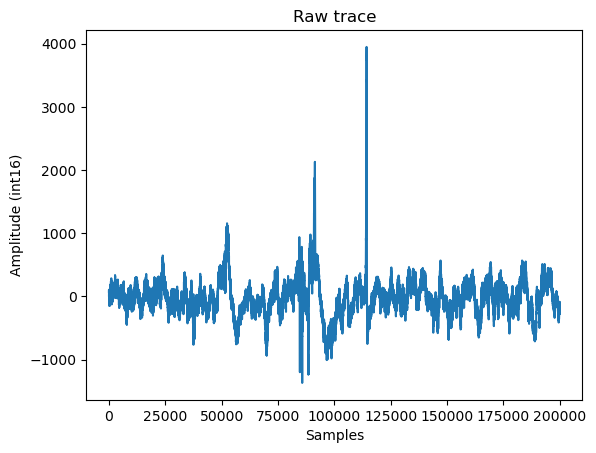

In [ ]:
elec_noise_freq=60
# https://pmc.ncbi.nlm.nih.gov/articles/PMC3130311/ paper suggested these min and max cut offs
min_freq=30
max_freq=1000
resample_rate=1000
# Extract traces from the first segment
# For example, get the first 10 seconds of data from channel 0
sampling_rate = recording.get_sampling_frequency()
duration_sec = 10
num_samples = int(duration_sec * sampling_rate)

traces = recording.get_traces(start_frame=0, end_frame=num_samples, channel_ids=['10'])
plt.plot(traces)
plt.title("Raw trace")
plt.xlabel("Samples")
plt.ylabel("Amplitude (int16)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Get recording information
sampling_rate = recording.get_sampling_frequency()
total_samples = recording.get_num_samples()
total_seconds = int(total_samples // sampling_rate)  # Explicitly make this an integer
channel = '20'  # Your channel of interest

# Loop over every second
for second in range(total_seconds):
    start_frame = int(second * sampling_rate)
    end_frame = int((second + 1) * sampling_rate)

    traces = recording.get_traces(start_frame=start_frame, end_frame=end_frame, channel_ids=[channel])

    # Plot
    plt.figure(figsize=(10, 3))
    plt.plot(traces)
    plt.title(f"Second {second} of the recording (Channel {channel})")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude (int16)")
    plt.show()


: 